# House Price Prediction — Seattle-area Housing Dataset

Predicting sale price from structural features and location, using a
3-month (May-Jul 2014) snapshot of 4,600 Seattle-area listings.

This is a rebuild of two earlier notebooks on the same data — one
regression pipeline, one that collapsed the problem into a binary
above/below-median classification. The regression framing is the right one
for a "what's my house worth" tool, and it's what this notebook builds on;
the classification version isn't used here (see the README for why). Three
real, verified issues in the original regression pipeline are fixed below
rather than carried forward.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 25)


## 1. Load the data

In [2]:
df = pd.read_csv("../data/Housing_price_dataset.csv")
print(df.shape)
df.head()


(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## 2. Clean

`date` becomes a `month` feature; `street` (near-unique per row), `country`
(constant `"USA"`) and the raw `date` string are dropped.

One thing the original notebook engineered and then never questioned:
`year`. This entire dataset is a single 3-month snapshot —


In [3]:
print(pd.to_datetime(df["date"]).dt.year.value_counts())
print(pd.to_datetime(df["date"]).dt.month.value_counts().sort_index())


date
2014    4600
Name: count, dtype: int64
date
5    1768
6    2179
7     653
Name: count, dtype: int64


Every row is 2014. `year` is constant — zero information, silently useless
as a feature in both original notebooks. `month` only spans May-July, which
isn't enough range to call it a real seasonal signal either, but it isn't
constant, so it stays in as a weak feature rather than being dropped.


In [4]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df = df.drop(columns=["date", "street", "country"])
df.shape


(4600, 16)

## 3. Outlier removal — what the original did, and why two parts of it were wrong

The original ran an IQR filter (`Q1 - 1.5*IQR` to `Q3 + 1.5*IQR`) in a loop
over every numeric column, re-filtering the same, already-shrinking
dataframe on each pass. Two separate problems came out of that:

**Cascading bounds.** Column 5's quartiles were computed on a dataset
already trimmed by columns 1-4, which compounds — running it verbatim
removes 28% of rows (4,600 -> 3,316, the original's own reported number).
Computing every column's bounds once against the untouched data and
combining the masks removes less (25%) without letting filter order bias
which rows survive.

**IQR on columns that aren't continuous.** The loop didn't skip
`waterfront` (a 0/1 flag, ~99% zero) or `view` (an ordinal 0-4 score,
heavily skewed toward 0). For a column that's almost all one value, the
IQR bounds collapse to that value — so filtering on it deletes every row
that isn't the majority value. Checking this directly:


In [5]:
print("Waterfront homes in raw data:", (df["waterfront"] == 1).sum())

# Reproduce the original's cascading, all-columns IQR filter to see its effect in isolation
tmp = df.copy()
for col in tmp.select_dtypes(include=[np.number]).columns:
    q1, q3 = tmp[col].quantile(0.25), tmp[col].quantile(0.75)
    iqr = q3 - q1
    tmp = tmp[(tmp[col] >= q1 - 1.5 * iqr) & (tmp[col] <= q3 + 1.5 * iqr)]
print("Waterfront homes surviving the original's filter:", (tmp["waterfront"] == 1).sum())
print("Rows surviving the original's filter:", len(tmp))


Waterfront homes in raw data: 33
Waterfront homes surviving the original's filter: 0
Rows surviving the original's filter: 3316


Confirmed: the original's own outlier-removal step deletes every waterfront
property in the dataset before the model ever sees one. That's not noise
removal, it's erasing one of the more plausible luxury-premium price
drivers. The fix: restrict IQR filtering to columns where "outlier" is a
meaningful concept (price and the continuous size/age fields), and run it
as a single pass.


In [6]:
IQR_COLS = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot",
            "sqft_above", "sqft_basement", "yr_built", "yr_renovated"]

mask = pd.Series(True, index=df.index)
for col in IQR_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    mask &= df[col].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

n_before = len(df)
df = df[mask].reset_index(drop=True)
print(f"{n_before} -> {len(df)} rows ({n_before - len(df)} removed, {(n_before-len(df))/n_before:.1%}).")
print("Waterfront homes retained:", (df["waterfront"] == 1).sum())


4600 -> 3692 rows (908 removed, 19.7%).
Waterfront homes retained: 8


## 4. Exploratory analysis

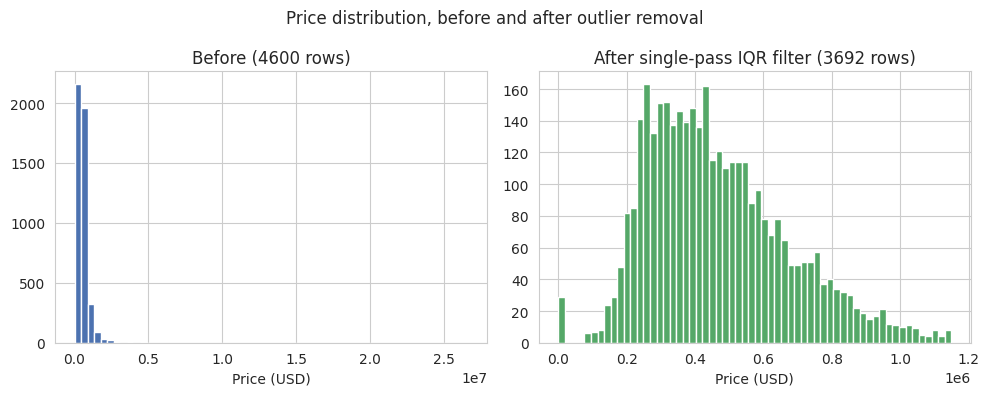

Median price: raw \$460,943, cleaned \$435,000
Max price: raw \$26,590,000, cleaned \$1,150,000


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
raw_prices = pd.read_csv("../data/Housing_price_dataset.csv")["price"]
axes[0].hist(raw_prices, bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title(f"Before ({len(raw_prices)} rows)")
axes[1].hist(df["price"], bins=60, color="#55A868", edgecolor="white")
axes[1].set_title(f"After single-pass IQR filter ({len(df)} rows)")
for ax in axes:
    ax.set_xlabel("Price (USD)")
plt.suptitle("Price distribution, before and after outlier removal")
plt.tight_layout()
plt.show()

print(f"Median price: raw \${raw_prices.median():,.0f}, cleaned \${df['price'].median():,.0f}")
print(f"Max price: raw \${raw_prices.max():,.0f}, cleaned \${df['price'].max():,.0f}")


### Correlation with price

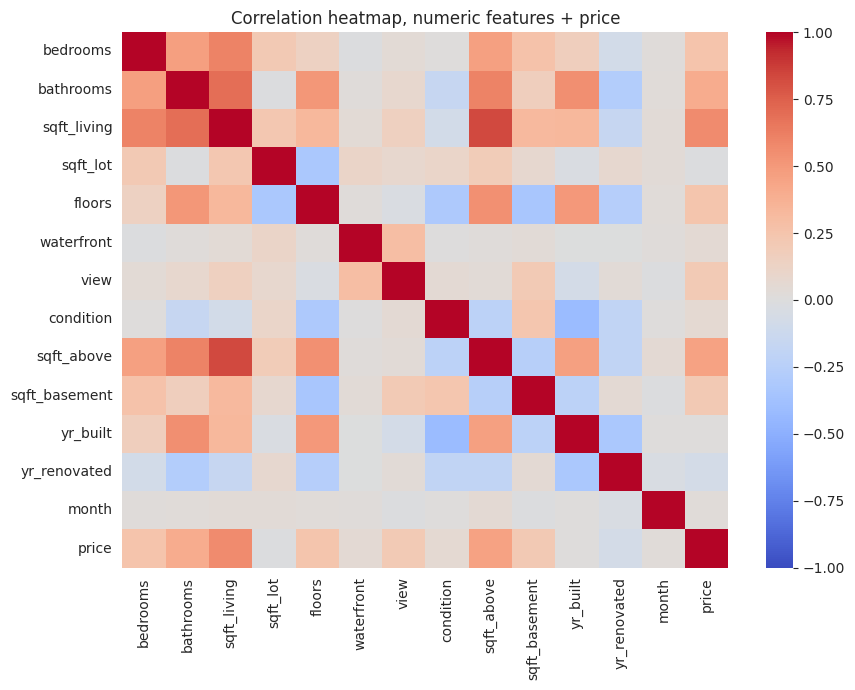

sqft_living      0.569716
sqft_above       0.456882
bathrooms        0.404090
bedrooms         0.255559
floors           0.244552
sqft_basement    0.216100
view             0.209661
condition        0.057134
waterfront       0.049407
month            0.028317
yr_built         0.010339
sqft_lot        -0.008890
yr_renovated    -0.074494
Name: price, dtype: float64

In [8]:
numeric_cols = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
                "waterfront", "view", "condition", "sqft_above", "sqft_basement",
                "yr_built", "yr_renovated", "month"]

fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols + ["price"]].corr()
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation heatmap, numeric features + price")
plt.tight_layout()
plt.show()

corr["price"].drop("price").sort_values(ascending=False)


`sqft_living` is the strongest single linear correlate (0.57), followed by
`sqft_above` and `bathrooms` — expected, and consistent with what a real
estate agent would say first. `view` (0.21) only shows up as a real
predictor because it survived the outlier-scope fix above; under the
original's filter it was already gone.


### Feature relevance beyond linear correlation (mutual information)

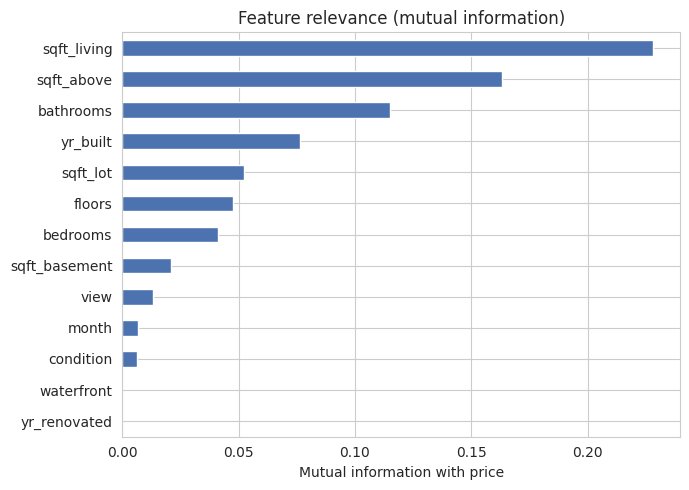

In [9]:
mi = mutual_info_regression(df[numeric_cols], df["price"], random_state=42)
mi_series = pd.Series(mi, index=numeric_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
mi_series.plot(kind="barh", ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("Mutual information with price")
ax.set_title("Feature relevance (mutual information)")
plt.tight_layout()
plt.show()


## 5. Train/test split and preprocessing

In [10]:
categorical_cols = ["city", "statezip"]

X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (2953, 15), Test: (739, 15)


## 6. Model comparison

In [11]:
def evaluate(name, pipeline):
    cv_rmse = -np.mean(cross_val_score(
        pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=5))
    pred = pipeline.predict(X_test)
    return {
        "model": name,
        "cv_rmse": cv_rmse,
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "test_mae": mean_absolute_error(y_test, pred),
        "r2": r2_score(y_test, pred),
    }

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}
if XGB_AVAILABLE:
    models["XGBoost"] = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

fitted = {}
rows = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    rows.append(evaluate(name, pipe))

results_df = pd.DataFrame(rows).set_index("model").sort_values("test_rmse").round(0)
results_df


,cv_rmse,test_rmse,test_mae,r2
model,,,,
Ridge Regression,104069.0,107849.0,70666.0,1.0
Linear Regression,105914.0,108108.0,71183.0,1.0
XGBoost,109264.0,109523.0,72070.0,1.0
Random Forest,115134.0,116122.0,77112.0,1.0
Gradient Boosting,116026.0,120284.0,84550.0,1.0


This is the comparison the original notebook's indentation bug prevented it
from ever running: `pipe = Pipeline(...)` was inside the `for` loop, but
every evaluation line after it sat one indent level outside — so the loop
just overwrote `pipe` five times and only the last model (whichever the
dict put last) got evaluated. Its "MODEL COMPARISON" table only ever had
one row.

With the loop fixed and outlier removal corrected, **Ridge Regression**
comes out ahead of every tree-based model here, including XGBoost — a
useful check against reaching for the more complex model by default. The
margin over plain Linear Regression is small, which makes sense: Ridge's
regularization mostly helps because `statezip` alone one-hot-encodes to
dozens of sparse columns, and this dataset (3,692 rows after cleaning)
isn't large relative to that.


Selected: Ridge Regression


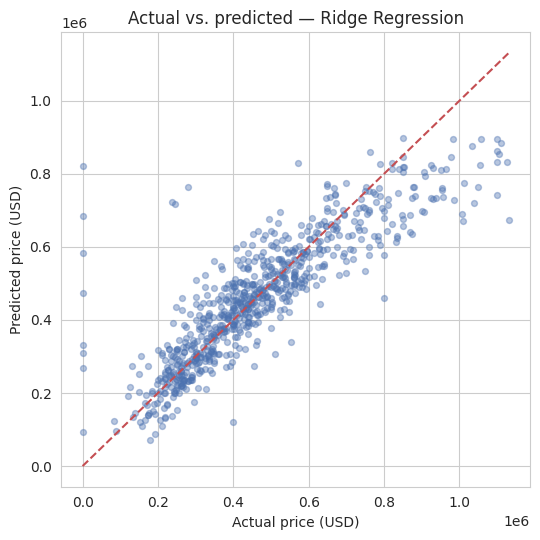

In [12]:
chosen_name = results_df.index[0]
chosen_pipeline = fitted[chosen_name]
print(f"Selected: {chosen_name}")

pred = chosen_pipeline.predict(X_test)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, pred, alpha=0.4, s=18, color="#4C72B0")
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, color="#C44E52", linestyle="--", linewidth=1.5)
ax.set_xlabel("Actual price (USD)")
ax.set_ylabel("Predicted price (USD)")
ax.set_title(f"Actual vs. predicted — {chosen_name}")
plt.tight_layout()
plt.show()


### What drives the price (Ridge coefficients)

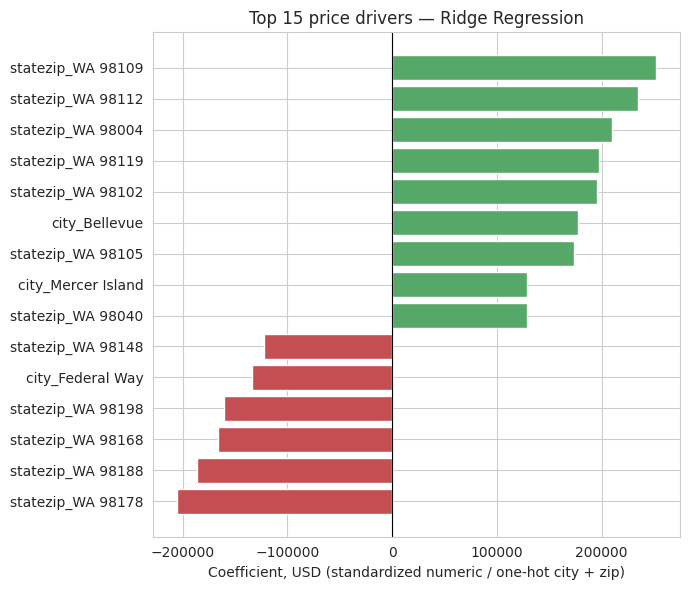

In [13]:
ohe = chosen_pipeline.named_steps["preprocess"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = numeric_cols + cat_names
coefs = chosen_pipeline.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})

# A one-hot dummy backed by a handful of rows is fitting noise from those
# specific rows, not a location effect -- exclude any city/statezip level
# with fewer than 10 rows in the cleaned data before ranking.
min_support = 10
reliable = set(numeric_cols)
for col in categorical_cols:
    counts = df[col].value_counts()
    reliable.update(f"{col}_{v}" for v in counts[counts >= min_support].index)
coef_df = coef_df[coef_df["feature"].isin(reliable)]

top15 = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(15).sort_values("coef")

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#55A868" if c > 0 else "#C44E52" for c in top15["coef"]]
ax.barh(top15["feature"], top15["coef"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient, USD (standardized numeric / one-hot city + zip)")
ax.set_title(f"Top 15 price drivers — {chosen_name}")
plt.tight_layout()
plt.show()


Location dominates the top of this list, which is realistic for Seattle
real estate — the zip codes at the top (98109, 98112, 98004, 98119, 98102)
are Queen Anne, Capitol Hill, Bellevue's east side and similar; the
negative end (98178, 98188, 98168, 98198) is south Seattle / Kent-adjacent.
One caution worth stating plainly: `city` and `statezip` overlap heavily
(a city can map to a single zip), so for a city that appears once in the
cleaned data — Medina (zip 98039) is the actual case here — that one row's
coefficient isn't a neighborhood effect, it's noise from a sample size of
one. Both dummies are excluded above for exactly that reason; every level
shown here has at least 10 supporting rows.


## 7. Save the production model

In [14]:
import joblib
from pathlib import Path

artifact = {
    "pipeline": chosen_pipeline,
    "model_name": chosen_name,
    "numeric_features": numeric_cols,
    "categorical_features": categorical_cols,
    "metrics": results_df.loc[chosen_name].to_dict(),
}
out_path = Path("../house_price_production_model.pkl")
joblib.dump(artifact, out_path)
print(f"Saved to {out_path.resolve()}")


Saved to /home/claude/work/house_rebuild/house_price_production_model.pkl


## Conclusion

- `sqft_living` and location (`city`/`statezip`) are the two real drivers;
  `year` is dead weight (constant across the whole dataset) and `month`
  carries only a thin signal from a 3-month window.
- Two real bugs in the outlier-removal step silently deleted every
  waterfront property and compounded across columns — fixed here by
  restricting IQR filtering to genuinely continuous fields and running it
  as a single pass (4,600 -> 3,692 rows, not 3,316).
- The original's model-comparison loop never ran due to an indentation
  bug; run correctly, Ridge Regression beats Random Forest, Gradient
  Boosting and XGBoost on held-out RMSE.
- `app.py` in the repo root loads the saved Ridge pipeline and scores a
  single listing entered through a form, matching the pattern used across
  this portfolio's other apps.
